# Capítulo 13 — Ciclones Extratropicais: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | vorticidade e sua advecção numa onda de 500 hPa | NumPy |
| 2 | instabilidade baroclínica: taxa de Eady | NumPy |
| 3 | *spin-up*: a EDO do ciclone (com e sem Ekman) | `solve_ivp` |
| 4 | os quatro quadrantes de um *jet streak* | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap13_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Omega, R_T = 9.8, 7.292e-5, 6.371e6
phi0 = -45.0
f0 = 2*Omega*np.sin(np.deg2rad(phi0))        # ~ -1.03e-4 s^-1 (HS!)

## Caso 1 — Vorticidade e advecção de vorticidade na onda de Rossby

Uma onda senoidal no jato de 500 hPa: $\psi = -U_0 y + A\cos(kx)\sin(ly)$. Calculamos $\zeta = \nabla^2\psi$ e a advecção $-\vec U\cdot\nabla(\zeta + f)$: no HS, **advecção de vorticidade (mais negativa) a leste do cavado** marca a região de levantamento e ciclogênese em superfície (Stull, §13.3).

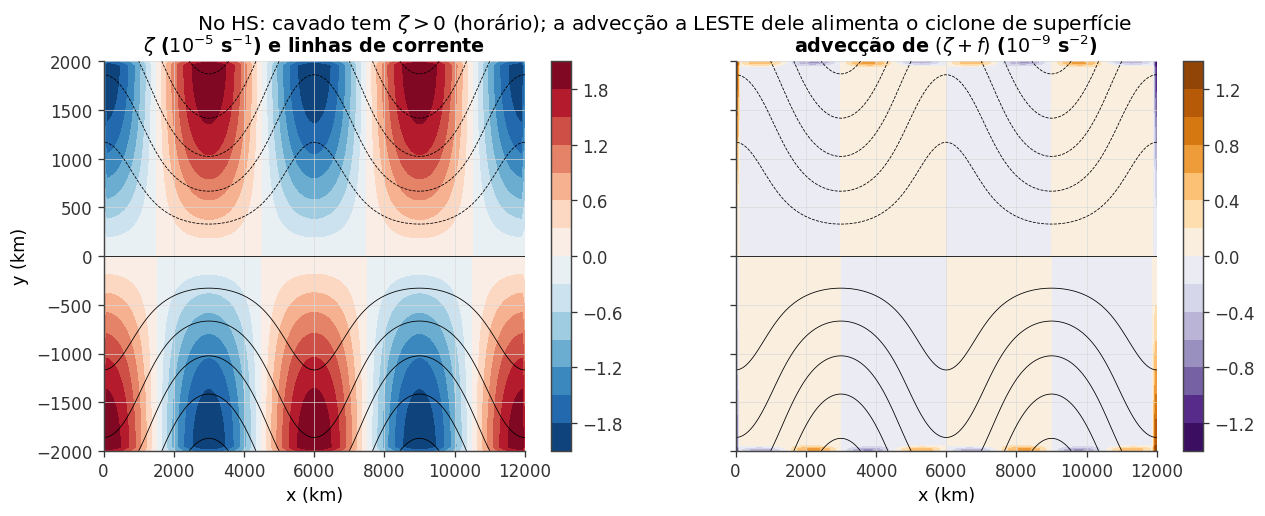

zeta max = 2.1e-5 1/s  (f0 = -10.3e-5 1/s):
vorticidade da onda ~ 20-30% de f — escoamento quase-geostrofico tipico.


In [2]:
L = 6000e3
x = np.linspace(0, 2*L, 300); y = np.linspace(-2000e3, 2000e3, 200)
X, Y = np.meshgrid(x, y)
U0, A = 15.0, 1.2e7
k, l = 2*np.pi/L, np.pi/4000e3
beta = 2*Omega*np.cos(np.deg2rad(phi0))/R_T

psi = -U0*Y + A*np.cos(k*X)*np.sin(l*Y)
u = -np.gradient(psi, y, axis=0)
v = np.gradient(psi, x, axis=1)
zeta = (np.gradient(np.gradient(psi, x, axis=1), x, axis=1) +
        np.gradient(np.gradient(psi, y, axis=0), y, axis=0))
adv = -(u*np.gradient(zeta, x, axis=1) + v*(np.gradient(zeta, y, axis=0) + beta))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
c1 = ax1.contourf(X/1e3, Y/1e3, zeta*1e5, levels=15, cmap='RdBu_r')
ax1.contour(X/1e3, Y/1e3, psi, levels=12, colors='k', linewidths=0.5)
ax1.set(title='$\\zeta$ ($10^{-5}$ s$^{-1}$) e linhas de corrente',
        xlabel='x (km)', ylabel='y (km)')
fig.colorbar(c1, ax=ax1)
c2 = ax2.contourf(X/1e3, Y/1e3, adv*1e9, levels=15, cmap='PuOr_r')
ax2.contour(X/1e3, Y/1e3, psi, levels=12, colors='k', linewidths=0.5)
ax2.set(title='advecção de $(\\zeta + f)$ ($10^{-9}$ s$^{-2}$)', xlabel='x (km)')
fig.colorbar(c2, ax=ax2)
fig.suptitle('No HS: cavado tem $\\zeta > 0$ (horário); a advecção a LESTE dele alimenta o ciclone de superfície')
plt.show()
print(f'zeta max = {zeta.max()*1e5:.1f}e-5 1/s  (f0 = {f0*1e5:.1f}e-5 1/s):')
print('vorticidade da onda ~ 20-30% de f — escoamento quase-geostrofico tipico.')

## Caso 2 — Por que existem ciclones? A taxa de Eady

A zona baroclínica é instável: perturbações extraem energia potencial do contraste térmico. O modelo de Eady dá a taxa de crescimento máxima
$$\sigma_{max} \simeq 0{,}31\,\frac{|f|}{N}\,\frac{\partial U}{\partial z},\qquad \lambda_{max} \simeq 3{,}9\,\frac{N\,H}{|f|},$$
com $H$ a profundidade da troposfera. Cisalhamento vem do vento térmico (Cap. 11) — inverno é temporada de ciclones.

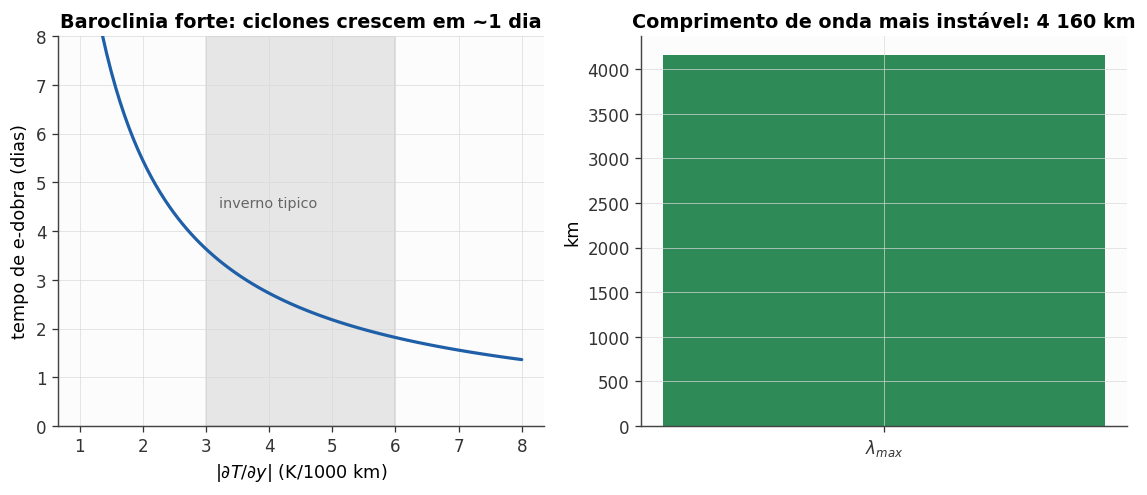

lambda_max = 4160 km — o tamanho dos ciclones nas cartas! —
e-dobra de 2.7 dias
para 4 K/1000 km: nasce segunda, madura quarta, oclui sexta.


In [3]:
N_bv, H = 0.011, 10e3
dTdy = np.linspace(1, 8, 100)*1e-6            # K/m (1 a 8 K por 1000 km)
T_med = 260.0
dUdz = g/(np.abs(f0)*T_med)*dTdy              # vento térmico
sigma = 0.31*np.abs(f0)/N_bv*dUdz
efold = 1/sigma/86400

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.plot(dTdy*1e6, efold, color=CORES['azul'], lw=2)
ax1.axvspan(3, 6, color=CORES['cinza'], alpha=0.15)
ax1.text(3.2, 4.5, 'inverno tipico', fontsize=9, color='#666666')
ax1.set(xlabel='$|\\partial T/\\partial y|$ (K/1000 km)', ylabel='tempo de e-dobra (dias)',
        title='Baroclinia forte: ciclones crescem em ~1 dia', ylim=(0, 8))
lam = 3.9*N_bv*H/np.abs(f0)
ax2.bar(['$\\lambda_{max}$'], [lam/1e3], color=CORES['verde'], width=0.4)
ax2.set(ylabel='km', title=f'Comprimento de onda mais instável: {lam/1e3:,.0f} km'.replace(',', ' '))
plt.show()
print(f'lambda_max = {lam/1e3:.0f} km — o tamanho dos ciclones nas cartas! —')
print(f'e-dobra de {1/(0.31*np.abs(f0)/N_bv*(g/(np.abs(f0)*T_med))*4e-6)/86400:.1f} dias')
print('para 4 K/1000 km: nasce segunda, madura quarta, oclui sexta.')

## Caso 3 — *Spin-up*: a EDO do ciclone

O esticamento gera vorticidade; o atrito de Ekman a consome:
$$\frac{d\zeta}{dt} = -(f + \zeta)\,D \;-\; \frac{\zeta}{\tau_E},\qquad \tau_E \sim 2\text{–}4\ \text{dias},$$
com $D = \nabla\cdot\vec U_h < 0$ (convergência) imposta pela dinâmica de altitude (Caso 1). Previsão numérica em miniatura do enrolamento do ciclone.

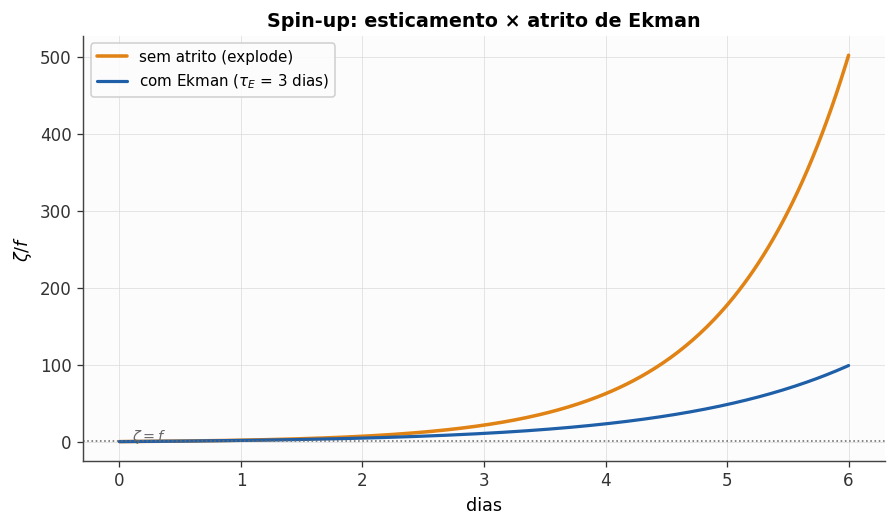

equilibrio com atrito: zeta_eq/f = 98.87
sem atrito o termo -(f+zeta)D e explosivo (crescimento super-exponencial);
o Ekman poe o teto — e e ele que mata o ciclone quando a divergencia de altitude some.


In [4]:
D = -1.2e-5                                    # convergência (1/s)
tau_E = 3*86400

def spinup(t, z, com_atrito):
    return -(f0 + z[0])*D - (z[0]/tau_E if com_atrito else 0.0)

dias = 6
t_eval = np.linspace(0, dias*86400, 300)
s1 = solve_ivp(spinup, [0, dias*86400], [0.0], args=(False,), t_eval=t_eval, rtol=1e-8)
s2 = solve_ivp(spinup, [0, dias*86400], [0.0], args=(True,), t_eval=t_eval, rtol=1e-8)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(t_eval/86400, s1.y[0]/f0, color=CORES['laranja'], label='sem atrito (explode)')
ax.plot(t_eval/86400, s2.y[0]/f0, color=CORES['azul'], lw=2, label='com Ekman ($\\tau_E$ = 3 dias)')
ax.axhline(1, color=CORES['cinza'], ls=':', lw=1)
ax.text(0.1, 1.05, '$\\zeta = f$', fontsize=9, color='#666666')
ax.set(xlabel='dias', ylabel='$\\zeta/f$',
       title='Spin-up: esticamento × atrito de Ekman')
ax.legend()
plt.show()
zeq = -f0*D*tau_E/(1 + D*tau_E)
print(f'equilibrio com atrito: zeta_eq/f = {float(s2.y[0][-1]/f0):.2f}')
print('sem atrito o termo -(f+zeta)D e explosivo (crescimento super-exponencial);')
print('o Ekman poe o teto — e e ele que mata o ciclone quando a divergencia de altitude some.')

## Caso 4 — Os quatro quadrantes do *jet streak*

Um máximo local de vento no jato (streak) obriga o ar a acelerar na entrada e frear na saída; o vento ageostrófico resultante produz o padrão clássico de divergência em quatro quadrantes — e a divergência em altitude é o gatilho da ciclogênese em superfície.

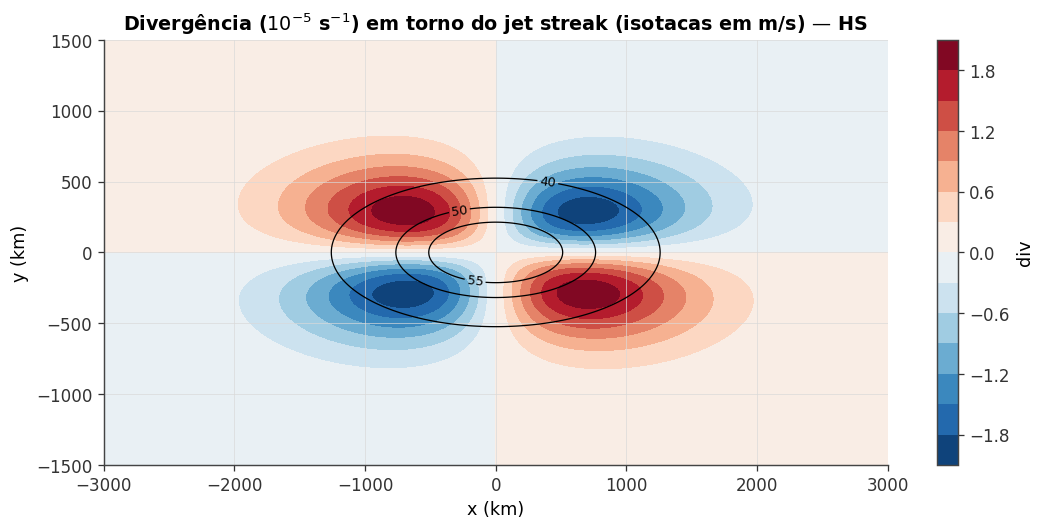

quadrantes com DIVERGENCIA em altitude (vermelho) => succao => ciclogenese
embaixo deles; no HS sao a entrada polar e a saida equatorial do streak.


In [5]:
x = np.linspace(-3000e3, 3000e3, 400); y = np.linspace(-1500e3, 1500e3, 240)
X, Y = np.meshgrid(x, y)
U_jet = 30.0 + 30.0*np.exp(-(X/1200e3)**2 - (Y/500e3)**2)

# vento ageostrófico ~ (1/f) dU/dt ~ (U/f) dU/dx (aceleração ao longo do jato)
dUdx = np.gradient(U_jet, x, axis=1)
v_ag = U_jet*dUdx/f0                           # transversal (HS: sinal!)
div = np.gradient(v_ag, y, axis=0)

fig, ax = plt.subplots(figsize=(11, 4.8))
cf = ax.contourf(X/1e3, Y/1e3, div*1e5, levels=15, cmap='RdBu_r')
cs = ax.contour(X/1e3, Y/1e3, U_jet, levels=[40, 50, 55], colors='k', linewidths=0.8)
ax.clabel(cs, fmt='%d', fontsize=8)
ax.set(xlabel='x (km)', ylabel='y (km)',
       title='Divergência ($10^{-5}$ s$^{-1}$) em torno do jet streak (isotacas em m/s) — HS')
fig.colorbar(cf, label='div')
plt.show()
print('quadrantes com DIVERGENCIA em altitude (vermelho) => succao => ciclogenese')
print('embaixo deles; no HS sao a entrada polar e a saida equatorial do streak.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap13_solucoes.ipynb`**.

**N1** — No Caso 1, varra a amplitude $A$ da onda e trace o máximo da advecção de vorticidade contra $A$; a partir de que amplitude a $\zeta$ do cavado supera $|f|/2$?

**N2** — Com $\partial T/\partial y$ mensal típico do HS (janeiro a dezembro, fornecido no enunciado), trace o ciclo sazonal do tempo de e-dobra de Eady; em que meses a 'temporada de ciclones' do Atlântico Sul é prevista?

**N3** — No Caso 3, desligue a convergência ($D = 0$) no dia 3 e observe o decaimento; meça o tempo de vida total do ciclone para $\tau_E$ = 2, 3 e 5 dias.

**N4** — No Caso 4, dobre a intensidade do streak e meça o máximo de divergência; estime o $w$ no nível médio por continuidade ($w \sim -D\,\Delta z$) e compare com os cm/s do levantamento sinótico (Cap. 10).

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*